## Background Noise Evelope Analysis

#### Packages and utils

In [1]:
import numpy as np
from utils.dfa_utils import dfa

def windowed_features(signal_data, win_size=1024, overlap=0.5):
    step = int(win_size * (1 - overlap))
    n_windows = (len(signal_data) - win_size) // step + 1
    
    rms_list, dfa_list = [], []
    
    for i in range(n_windows):
        start = i * step
        end = start + win_size
        window = signal_data[start:end]
        
        if len(window) < win_size:
            break
        
        # --- Raw metrics ---
        rms = np.sqrt(np.mean(window**2))
        dfa_val, _, _, _ = dfa(window)  # Only take alpha value from custom DFA
        
        rms_list.append(rms)
        dfa_list.append(dfa_val)
    
    return (
        np.array(rms_list),
        np.array(dfa_list)
    )

c:\Users\Cathy\Repositories\DistanceNoise\.venv\Lib\site-packages\nolds\datasets.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#### Study 1

Binaural (2-channel - left/right ear) headphone sound files with a sampling frequency of 44100 Hz.

##### Processes a single .wav file and returns graphs

Loaded background_noises_study1/1 Library.wav | Original SR: 44100, Length: 120.0s
Downsampled envelope | SR=47, Length=5640 samples
Computed 11 windows of features


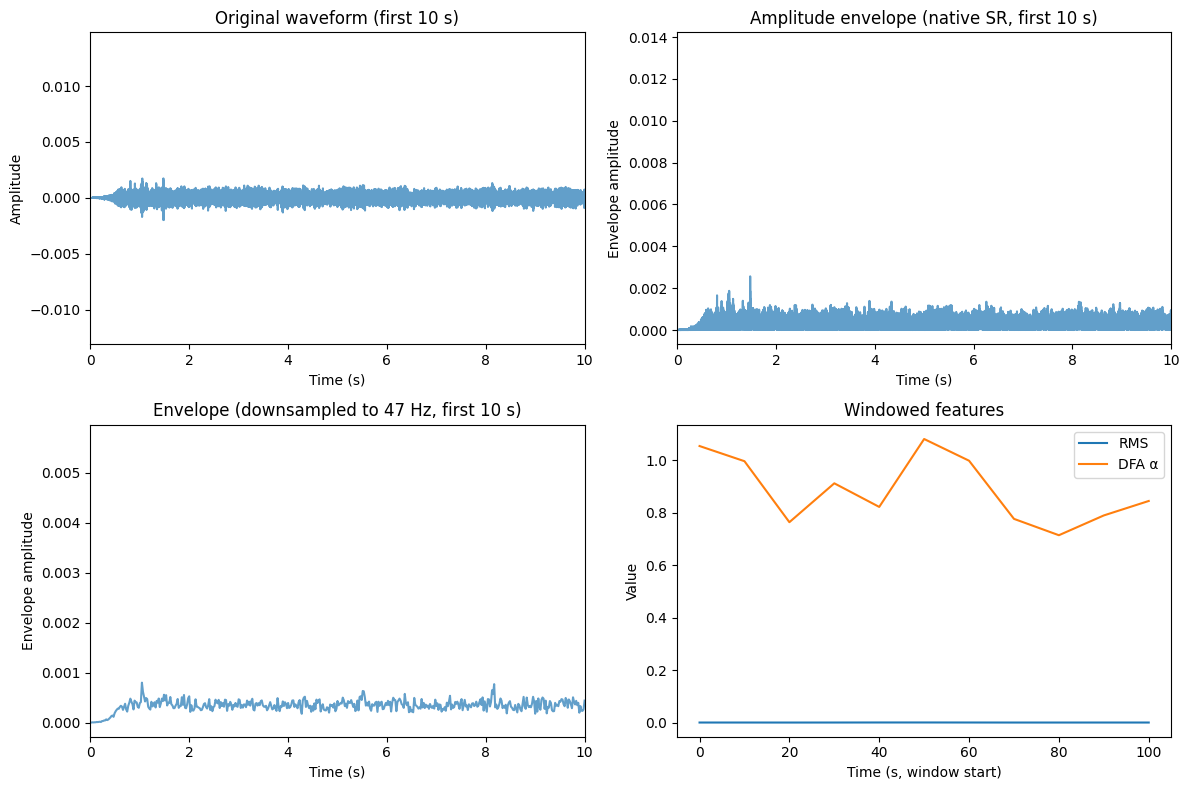

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import librosa

# === PARAMETERS ===
wav_file = "stimuli/study1/1 Library.wav"
target_sr = 47        # downsample to match motion data
duration = None       # seconds to analyze (None = full file)
win_size = 940       # window length in samples (at 47 Hz)
overlap = 0.5         # 50% overlap

# === 1. LOAD AUDIO ===
y, sr = librosa.load(wav_file, sr=None, mono=True, duration=duration)
print(f"Loaded {wav_file} | Original SR: {sr}, Length: {len(y)/sr:.1f}s")

# === 2. ENVELOPE ===
analytic = signal.hilbert(y)
envelope = np.abs(analytic)

# === 3. DOWNSAMPLE TO TARGET SR ===
envelope_down = librosa.resample(envelope, orig_sr=sr, target_sr=target_sr)
print(f"Downsampled envelope | SR={target_sr}, Length={len(envelope_down)} samples")

# === 4. WINDOWED FEATURES ===
rms_vals, dfa_vals = windowed_features(envelope_down, win_size, overlap)
print(f"Computed {len(rms_vals)} windows of features")

# === 5. PLOTS ===
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

# (a) Original waveform (first 10 s)
axs[0].plot(np.linspace(0, len(y)/sr, len(y)), y, alpha=0.7)
axs[0].set_xlim(0, 10)
axs[0].set_title("Original waveform (first 10 s)")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Amplitude")

# (b) Envelope (native SR, first 10 s)
axs[1].plot(np.linspace(0, len(envelope)/sr, len(envelope)), envelope, alpha=0.7)
axs[1].set_xlim(0, 10)
axs[1].set_title("Amplitude envelope (native SR, first 10 s)")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Envelope amplitude")

# (c) Downsampled envelope (first 10 s)
axs[2].plot(np.linspace(0, len(envelope_down)/target_sr, len(envelope_down)), envelope_down, alpha=0.7)
axs[2].set_xlim(0, 10)
axs[2].set_title(f"Envelope (downsampled to {target_sr} Hz, first 10 s)")
axs[2].set_xlabel("Time (s)")
axs[2].set_ylabel("Envelope amplitude")

# (d) Windowed RMS & DFA time series
time_windows = np.arange(len(rms_vals)) * (win_size * (1 - overlap)) / target_sr
axs[3].plot(time_windows, rms_vals, label="RMS", color="tab:blue")
axs[3].plot(time_windows, dfa_vals, label="DFA α", color="tab:orange")
axs[3].set_title("Windowed features")
axs[3].set_xlabel("Time (s, window start)")
axs[3].set_ylabel("Value")
axs[3].legend()

plt.tight_layout()
plt.show()

##### Batch processes all background noise files using a windowed analysis

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy import signal
import librosa

# === PARAMETERS ===
folder = "stimuli/study1"
target_sr = 47
win_size = 940
overlap = 0.5

# === MASTER SUMMARY LIST ===
summary_records = []

for file in os.listdir(folder):
    if not file.endswith(".wav"):
        continue

    filepath = os.path.join(folder, file)
    print(f"Processing {filepath}...")

    # Load mono audio (librosa normalises peak to ±1)
    y, sr = librosa.load(filepath, sr=None, mono=True)

    # Envelope
    analytic = signal.hilbert(y)
    envelope = np.abs(analytic)

    # Downsample
    envelope_down = librosa.resample(envelope, orig_sr=sr, target_sr=target_sr)

    # Windowed features
    rms_vals, dfa_vals = windowed_features(envelope_down, win_size, overlap)

    # Save per-window CSV
    out_csv = os.path.join(folder, f"{os.path.splitext(file)[0]}_windows.csv")
    df_out = pd.DataFrame({
        "window_index": np.arange(len(rms_vals)),
        "rms_noise": rms_vals,
        "alpha_noise": dfa_vals
    })
    df_out.to_csv(out_csv, index=False)

    # Append summary stats
    summary_records.append({
        "File": file,
        "Mean_rms_noise": np.mean(rms_vals),
        "Mean_alpha_noise": np.mean(dfa_vals),
        "N_Windows": len(rms_vals)
    })

# Save master summary
summary_df = pd.DataFrame(summary_records)
summary_df.to_csv(os.path.join(folder, "noise_summary.csv"), index=False)

print("✅ Done! Per-window CSVs + summary saved.")

Processing background_noises_study1\1 Library.wav...
Processing background_noises_study1\2 Living.wav...
Processing background_noises_study1\2 Living.wav...
Processing background_noises_study1\3 Cafe 2.wav...
Processing background_noises_study1\3 Cafe 2.wav...
Processing background_noises_study1\4 Train.wav...
Processing background_noises_study1\4 Train.wav...
Processing background_noises_study1\5 Food Court 2.wav...
Processing background_noises_study1\5 Food Court 2.wav...
Processing background_noises_study1\6 No Music Party.wav...
Processing background_noises_study1\6 No Music Party.wav...
Processing background_noises_study1\7 Music Party.wav...
Processing background_noises_study1\7 Music Party.wav...
✅ Done! Per-window CSVs + summary saved.
✅ Done! Per-window CSVs + summary saved.


#### Study 2

##### Processes single .wav files

Loaded background_noises_study2/Party_Crossfade.wav | Native SR: 48000, Channels: 8, Length: 480.5s
Playing first 10s of averaged mono...
Computed 47 windows of features
Saved windowed results to background_noises_study2/Party_Crossfade_windows.csv
Computed 47 windows of features
Saved windowed results to background_noises_study2/Party_Crossfade_windows.csv


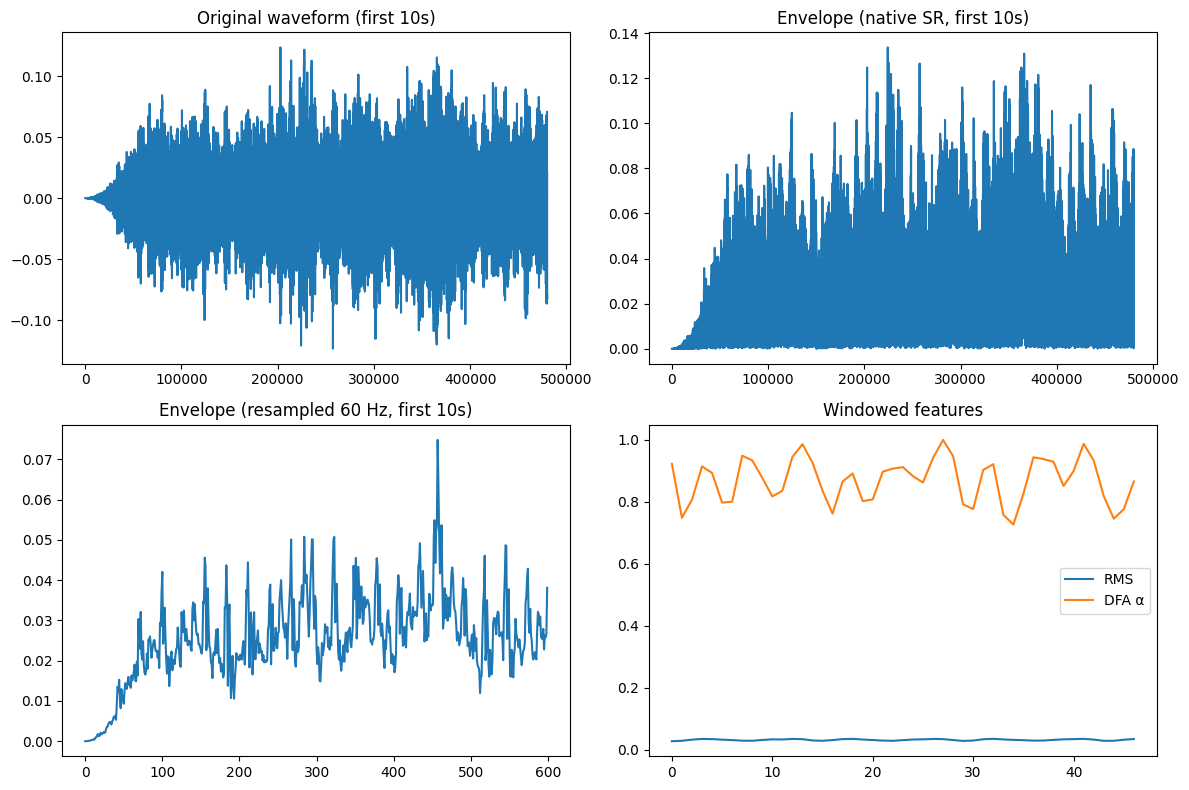

In [ ]:
import soundfile as sf
import sounddevice as sd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import librosa

# === PARAMETERS ===
wav_file = "stimuli/study2/Party_Crossfade.wav"
target_sr = 60
win_size = 1200
overlap = 0.5
playback = True   # set True to listen to first 10s

# === 1. LOAD AUDIO (multi-channel at native SR) ===
y, sr = sf.read(wav_file)  # shape: (samples, channels)
print(f"Loaded {wav_file} | Native SR: {sr}, Channels: {y.shape[1]}, Length: {len(y)/sr:.1f}s")

# Average first 2 channels to mono
noise_mono = np.mean(y[:, :2], axis=1)

if playback:
    print("Playing first 10s of averaged mono...")
    sd.play(noise_mono[:sr*10], sr)
    sd.wait()

# === 2. ENVELOPE (Hilbert at native SR) ===
analytic = signal.hilbert(noise_mono)
envelope = np.abs(analytic)

# === 3. RESAMPLE ENVELOPE TO 60 Hz ===
envelope_down = librosa.resample(envelope, orig_sr=sr, target_sr=target_sr)

# === 4. WINDOWED FEATURES ===
rms_vals, dfa_vals = windowed_features(envelope_down, win_size, overlap)
print(f"Computed {len(rms_vals)} windows of features")

# === 5. SAVE RESULTS TO CSV ===
csv_out = wav_file.replace(".wav", "_windows.csv")
df_out = pd.DataFrame({
    "window_index": np.arange(len(rms_vals)),
    "rms_noise": rms_vals,
    "alpha_noise": dfa_vals
})
df_out.to_csv(csv_out, index=False)
print(f"Saved windowed results to {csv_out}")

# === 6. PLOTS ===
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

# (a) Original waveform (first 10s)
axs[0].plot(noise_mono[:sr*10])
axs[0].set_title("Original waveform (first 10s)")

# (b) Envelope (native SR, first 10s)
axs[1].plot(envelope[:sr*10])
axs[1].set_title("Envelope (native SR, first 10s)")

# (c) Resampled envelope (60 Hz, first 10s)
axs[2].plot(envelope_down[:target_sr*10])
axs[2].set_title("Envelope (resampled 60 Hz, first 10s)")

# (d) Windowed features
axs[3].plot(rms_vals, label="RMS", color="tab:blue")
axs[3].plot(dfa_vals, label="DFA α", color="tab:orange")
axs[3].legend()
axs[3].set_title("Windowed features")

plt.tight_layout()
plt.show()

#### Plots and ANOVAs

C:\Users\Cathy\AppData\Local\Temp\ipykernel_15624\3086184563.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("File", group_keys=False).apply(normalise_time)


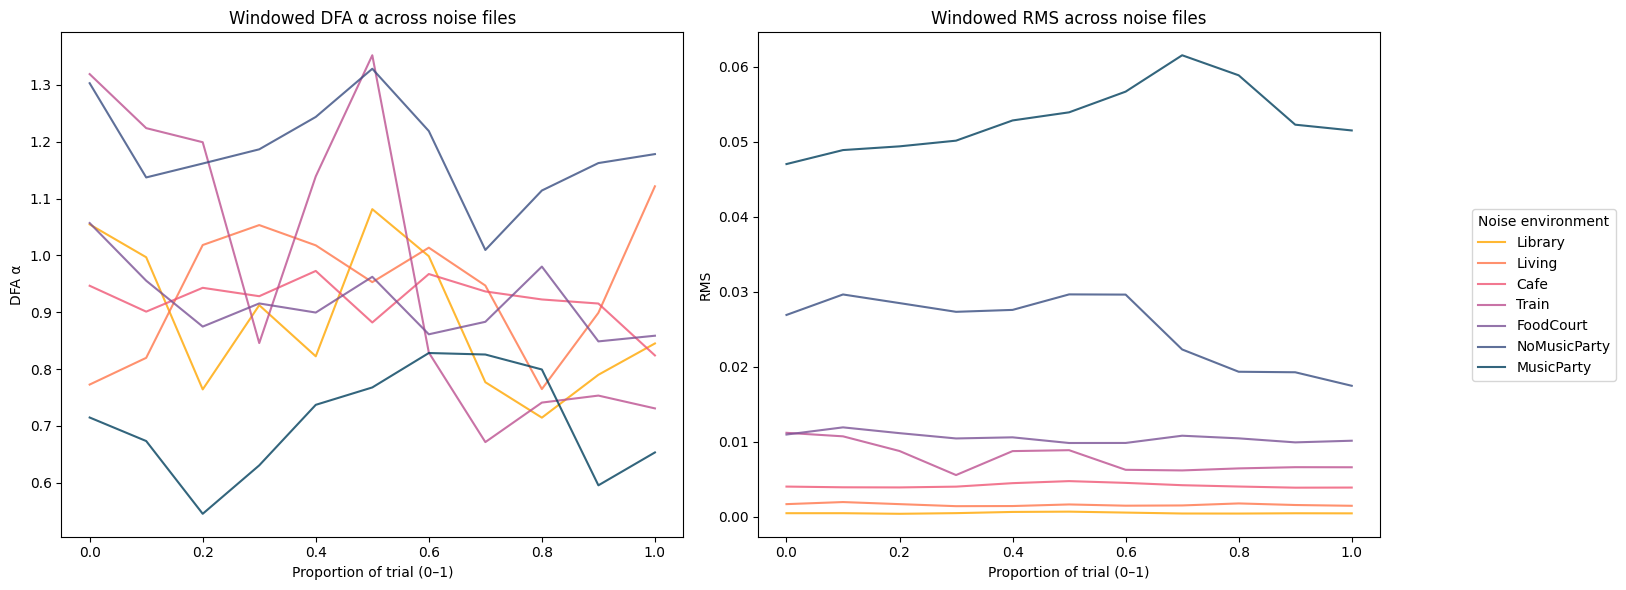

C:\Users\Cathy\AppData\Local\Temp\ipykernel_15624\3086184563.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Condition")[["alpha_noise", "rms_noise"]]


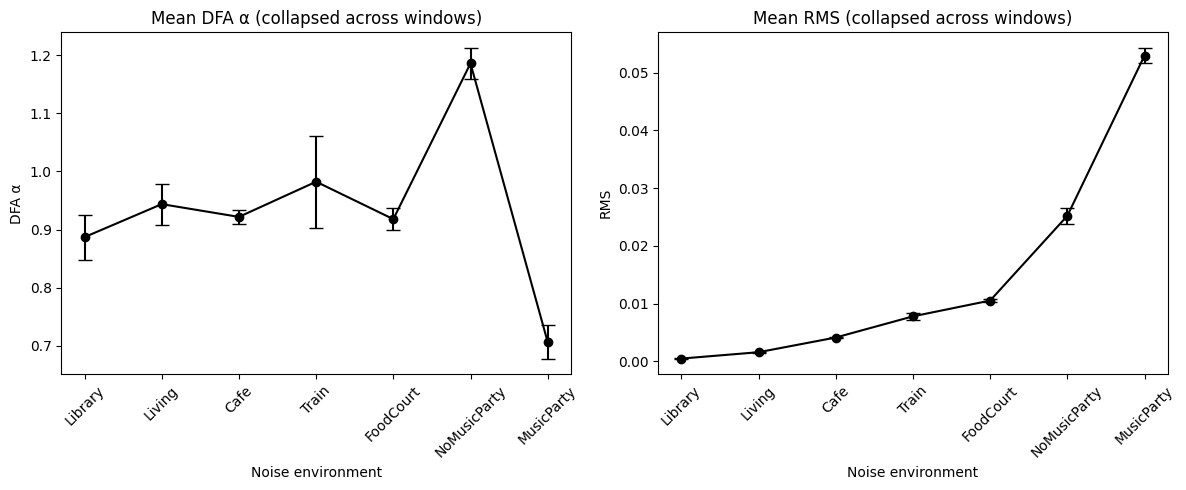


=== OLS ANOVA for alpha_noise ===
                             sum_sq    df          F        PR(>F)
C(Condition)               1.322374   6.0  19.469929  1.065423e-12
window_index               0.133041   1.0  11.752929  1.075757e-03
C(Condition):window_index  0.375716   6.0   5.531839  1.182230e-04
Residual                   0.713148  63.0        NaN           NaN

=== Tukey HSD pairwise comparisons (Condition) ===
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
        Cafe    FoodCourt  -0.0039    1.0 -0.1749  0.1672  False
        Cafe      Library  -0.0348 0.9961 -0.2058  0.1363  False
        Cafe       Living    0.022 0.9997 -0.1491   0.193  False
        Cafe   MusicParty  -0.2153 0.0051 -0.3863 -0.0443   True
        Cafe NoMusicParty   0.2641 0.0003   0.093  0.4351   True
        Cafe        Train   0.0605 0.9335 -0.1105  0.2315 

In [2]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# === PARAMETERS ===
folder = "background_noises_study1"   # change to study1 folder as needed
window_length = 20                    # seconds per DFA window

# --- MANUAL NOISE ORDER (quiet → loud) ---
study1_order = [
    "Library", "Living", "Cafe", "Train", "FoodCourt", "NoMusicParty", "MusicParty"
]
study2_order = [
    "Office", "Cafe", "FoodCourt", "Party"
]

# --- CUSTOM COLOURS ---
study1_colors = {
    "Library": "#ffa600",
    "Living": "#ff764a",
    "Cafe": "#ef5675",
    "Train": "#bc5090",
    "FoodCourt": "#7a5195",
    "NoMusicParty": "#374c80",
    "MusicParty": "#003f5c"
}
study2_colors = {
    "Office": "#fdc27efd",
    "Cafe": "#ef5675",
    "FoodCourt": "#7a5195",
    "Party": "#003f5c"
}

# === LOAD PER-WINDOW CSVs ===
csv_files = [f for f in os.listdir(folder) if f.endswith("_windows.csv")]
records = []

for csv in csv_files:
    df = pd.read_csv(os.path.join(folder, csv))
    file_id = csv.replace("_windows.csv", "").replace(".csv", "").strip()

    # --- CLEAN LABEL EXTRACTION ---
    name = re.sub(r"^\d+\s*", "", file_id)             # remove numeric prefixes
    name = re.sub(r"\s*\d+$", "", name)                # remove trailing digits
    name = re.sub(r"[_\s]*[Cc]rossfade$", "", name)    # remove crossfade suffixes
    label = name.replace("_", " ").strip()

    # --- NORMALISE KNOWN VARIANTS ---
    label = re.sub(r"(?i)food\s*court", "FoodCourt", label)
    label = re.sub(r"(?i)\bno\s*music\s*party\b", "NoMusicParty", label)
    label = re.sub(r"(?i)\bmusic\s*party\b", "MusicParty", label)
    label = re.sub(r"(?i)\bliving\s*room\b", "Living", label)

    for _, row in df.iterrows():
        records.append({
            "File": file_id,
            "Condition": label,
            "window_index": row["window_index"],
            "rms_noise": row["rms_noise"],
            "alpha_noise": row["alpha_noise"]
        })

data = pd.DataFrame(records)

# === APPLY CORRECT ORDER AND COLORS ===
if "study1" in folder.lower():
    order_list = study1_order
    color_map = study1_colors
else:
    order_list = study2_order
    color_map = study2_colors

data["Condition"] = data["Condition"].str.strip()
data["Condition"] = pd.Categorical(data["Condition"],
                                   categories=order_list,
                                   ordered=True)

# === NORMALISED TIME AXIS (0–1 PER FILE) ===
def normalise_time(df):
    max_time = df["window_index"].max() * window_length
    df = df.copy()
    df["norm_time"] = (df["window_index"] * window_length) / max_time
    return df

data = data.groupby("File", group_keys=False).apply(normalise_time)

# === PER-WINDOW PLOTS (NORMALISED DURATION) ===
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for name, group in data.groupby("File"):
    cond = group["Condition"].iloc[0]
    color = color_map.get(cond, "gray")
    group = group.sort_values("norm_time")

    axs[0].plot(group["norm_time"], group["alpha_noise"],
                label=cond, color=color, alpha=0.8, linewidth=1.5)
    axs[1].plot(group["norm_time"], group["rms_noise"],
                label=cond, color=color, alpha=0.8, linewidth=1.5)

axs[0].set(title="Windowed DFA α across noise files",
           xlabel="Proportion of trial (0–1)", ylabel="DFA α")
axs[1].set(title="Windowed RMS across noise files",
           xlabel="Proportion of trial (0–1)", ylabel="RMS")

# --- Legend (unique, clean labels) ---
handles, labels = axs[0].get_legend_handles_labels()
unique_labels = {}
for h, l in zip(handles, labels):
    clean = re.sub(r"\s*\d+$", "", l)
    unique_labels[clean] = h
fig.legend(unique_labels.values(), unique_labels.keys(),
           title="Noise environment", bbox_to_anchor=(1.05, 0.5),
           loc="center left")

plt.tight_layout()
plt.show()

# === COLLAPSED (MEAN ± SEM PER CONDITION) ===
summary = (
    data.groupby("Condition")[["alpha_noise", "rms_noise"]]
    .agg(["mean", "sem"])
    .reset_index()
)
summary.columns = ["Condition", "alpha_mean", "alpha_sem", "rms_mean", "rms_sem"]
summary = summary.sort_values("Condition")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].errorbar(summary["Condition"], summary["alpha_mean"],
                yerr=summary["alpha_sem"], fmt="o-", capsize=5, color="black")
axs[1].errorbar(summary["Condition"], summary["rms_mean"],
                yerr=summary["rms_sem"], fmt="o-", capsize=5, color="black")

axs[0].set(title="Mean DFA α (collapsed across windows)",
           ylabel="DFA α", xlabel="Noise environment")
axs[1].set(title="Mean RMS (collapsed across windows)",
           ylabel="RMS", xlabel="Noise environment")
for ax in axs:
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
plt.tight_layout()
plt.show()

# === ANOVA & DECOMPOSITION ===
ols_model = ols("alpha_noise ~ C(Condition) * window_index", data).fit()
print("\n=== OLS ANOVA for alpha_noise ===")
print(anova_lm(ols_model, typ=2))

# Clean inputs for Tukey
tukey_data = data.dropna(subset=["alpha_noise", "Condition"]).copy()
tukey_data["Condition"] = tukey_data["Condition"].astype(str)

try:
    tukey = pairwise_tukeyhsd(
        endog=tukey_data["alpha_noise"],
        groups=tukey_data["Condition"],
        alpha=0.05
    )
    print("\n=== Tukey HSD pairwise comparisons (Condition) ===")
    print(tukey)
except Exception as e:
    print("\n[Warning] Tukey HSD could not be computed:", e)

print("\n=== Simple slopes of window_index within each Condition ===")
for cond in data["Condition"].cat.categories:
    sub = data[data["Condition"] == cond]
    if sub.empty:
        continue
    slope_model = ols("alpha_noise ~ window_index", sub).fit()
    print(f"{cond}: slope = {slope_model.params['window_index']:.4f}, "
          f"p = {slope_model.pvalues['window_index']:.4f}")
